# 🎯 Detecting and Evaluating Cutback Opportunities


## 📖 0. What is a Cutback?

A cutback is a specific type of final pass, played from inside the opponent’s box, usually from the half-space near the byline, and directed low and backwards, often toward the penalty spot.

In this notebook, we define a cutback as:
- A pass **starting from the cutback delivery zone** (light green area),
- Ending in the **cutback target zone** (dark green area),
- With a **negative x-direction** (played backwards).

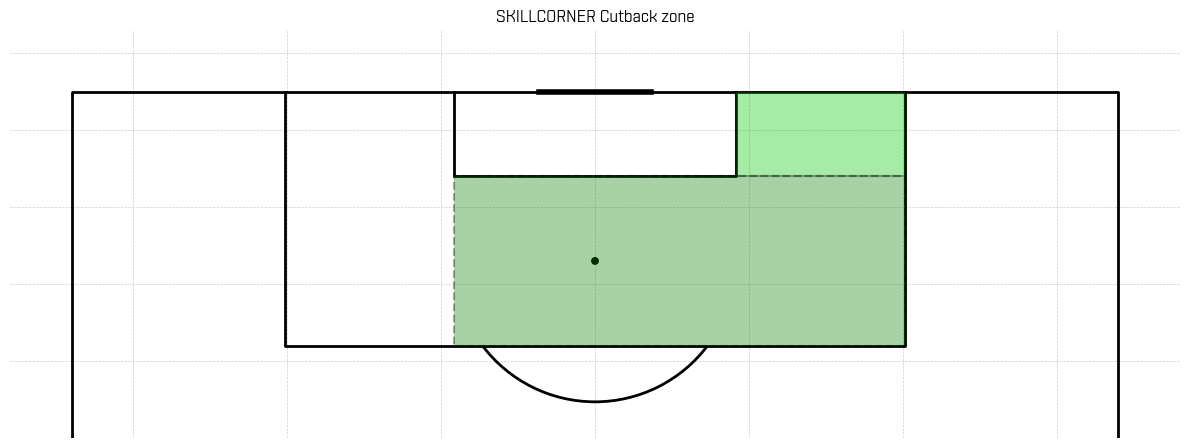

The following circle illustrates the full range of passing options available to the ball carrier, with the highlighted cone marking the angles that qualify as cutbacks: passes played backwards from wide areas into dangerous central zones.

### Cutback Analysis Workflow

![Cutback Analysis Workflow](../../../assets/cutback_workflow_diagram.png)


---


## 📋 1. Setup & Prerequisites


In [1]:

default_palette=["#00a82f", #  Green
    "#32fe6b", #  Lime
    "#7acbff", #  Pastel azure
    "#2388c8", #  Azure
    "#064c62"  #  Dark Azure
]
!pip install tqdm
import pandas as pd
import numpy as np
import json
import os
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
from mplsoccer import VerticalPitch
import matplotlib.pyplot as plt

# Options
pd.options.display.max_columns = None

# Using local Open Data paths
BASE_PATH = "../../../data"
MATCHES_DIR = os.path.join(BASE_PATH, "matches")


/Users/nano/PycharmProjects/opendata/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 📥 2. Load Match Data (Open Data)

We will iterate through the local `data/matches` directory to load Dynamic Events and Season Aggregates.

In [2]:
def process_local_match(match_id):
    try:
        match_dir = os.path.join(MATCHES_DIR, str(match_id))
        
        # Load Dynamic Events
        events_path = os.path.join(match_dir, f"{match_id}_dynamic_events.csv")
        # Added low_memory=False to silence DtypeWarning
        df_devents = pd.read_csv(events_path, low_memory=False)

        # Load Match Info for Pitch Dimensions and Player Minutes
        info_path = os.path.join(match_dir, f"{match_id}_match.json")
        with open(info_path, 'r') as f:
            match_info = json.load(f)
            
        # Extract Pitch Dimensions
        pitch_metadata = {
            'match_id': match_info['id'],
            'pitch_length': match_info.get('pitch_length', 105.0),
            'pitch_width': match_info.get('pitch_width', 68.0)
        }
        df_pitch_dim = pd.DataFrame([pitch_metadata])
        df_devents = df_devents.merge(df_pitch_dim, on='match_id', how='left')

        # Extract Player Minutes from match.json
        match_players = []
        for p in match_info.get('players', []):
            # Guard against players with missing playing_time (e.g. non-playing substitutes)
            playing_time = p.get('playing_time', {})
            total_time = playing_time.get('total') if isinstance(playing_time, dict) else None
            
            if total_time is not None:
                match_players.append({
                    'match_id': match_info['id'],
                    'player_id': p['id'],
                    'player_name': p['short_name'],
                    'team_id': p['team_id'],
                    'minutes_full_all': total_time.get('minutes_played', 0),
                    'minutes_full_tip': total_time.get('minutes_tip', 0),
                    'count_match': 1
                })
        df_minutes = pd.DataFrame(match_players)

        return df_devents, df_minutes
    except Exception as e:
        print(f"❌ Error match {match_id}: {e}")
        return None, None

# List matches and process (filtering for numeric match folders)
match_ids = [d for d in os.listdir(MATCHES_DIR) if d.isdigit() and os.path.isdir(os.path.join(MATCHES_DIR, d))]
all_devents = []
all_players = []

with ThreadPoolExecutor(max_workers=5) as executor:
    futures = {executor.submit(process_local_match, mid): mid for mid in match_ids}
    for future in tqdm(as_completed(futures), total=len(futures), desc="Loading Matches"):
        devents, p_minutes = future.result()
        if devents is not None and p_minutes is not None: 
            all_devents.append(devents)
            all_players.append(p_minutes)

if not all_devents:
    raise ValueError("❌ No matches were successfully loaded. Double-check your data paths!")

events_df = pd.concat(all_devents, ignore_index=True)

# Aggregate player minutes across matches
players_raw = pd.concat(all_players, ignore_index=True)
players_df = players_raw.groupby(['player_id', 'player_name', 'team_id']).agg({
    'minutes_full_all': 'sum',
    'minutes_full_tip': 'sum',
    'count_match': 'sum'
}).reset_index()

print(f"Loaded {len(events_df)} dynamic events and minutes for {len(players_df)} unique players across {len(all_devents)} matches.")


Loading Matches: 100%|██████████| 10/10 [00:00<00:00, 21.50it/s]

Loaded 47853 dynamic events and minutes for 206 unique players across 10 matches.


## 📐 3. Spatial Tagging of Cutbacks


### 4.1 Define Spatial Zones

In [3]:
# Define spatial zones for cutbacks (in meters, based on SkillCorner pitch)
CUTBACK_ZONES = {
    'delivery_zone': {
        'x_min_from_end': 5.5,       # 5.5m from goal line
        'y_min': 9.16,
        'y_max': 20.16
    },
    'target_zone': {
        'x_min_from_end': 16.5,      # 16.5m from goal line (surface)
        'x_max_from_end': 5.5,
        'y_min': -9.16,
        'y_max': 20.16
    }
}

DEFAULT_PITCH_LENGTH = 105

### 4.2 Cutback Detection Logic

In [4]:
def is_cutback(row, pitch_length=DEFAULT_PITCH_LENGTH, zones=CUTBACK_ZONES, angle_bounds=[-160, -110], margin=2.0):
    """
    Detects if an event is a cutback situation based on fixed delivery and target zones in meters.
    The pitch is assumed to be oriented with attack towards +x, and mirrored along y for consistency.
    Allows margin beyond pitch limits to account for off-field positions.
    """

    # Extract positions
    x_passer = row['player_in_possession_x_end']
    y_passer = row['player_in_possession_y_end']
    x_receiver = row['x_end']
    y_receiver = row['y_end']

    # Pass/Interplayer angle at pass moment
    angle = row.get("pass_angle", None)
    if angle is None or np.isnan(angle):
        if row.get("targeted") is True:
            angle = row.get("interplayer_angle", None)
        else:
            dx = row["x_end"] - row["player_in_possession_x_end"]
            dy = row["y_end"] - row["player_in_possession_y_end"]
            angle = np.degrees(np.arctan2(dy, dx))

    # Mirror passer's y to right side for consistency
    if y_passer < 0:
      y_passer = -y_passer
      y_receiver = -y_receiver
      angle = -angle

    # Delivery zone (passer)
    dz = zones['delivery_zone']
    dz_x_min = pitch_length / 2 - dz['x_min_from_end']
    dz_x_max = pitch_length / 2 + margin  # allow tolerance beyond pitch
    dz_y_min = dz['y_min']
    dz_y_max = dz['y_max']

    # Target zone (receiver)
    tz = zones['target_zone']
    tz_x_min = pitch_length / 2 - tz['x_min_from_end']
    tz_x_max = pitch_length / 2 - tz['x_max_from_end']
    tz_y_min = tz['y_min']
    tz_y_max = tz['y_max']

    # Checks
    in_passer_zone = (
        dz_x_min <= x_passer <= dz_x_max and
        dz_y_min <= y_passer <= dz_y_max
    )

    in_receiver_zone = (
        tz_x_min <= x_receiver <= tz_x_max and
        tz_y_min <= y_receiver <= tz_y_max
    )

    # Default cutback section = (-160°, -110°)
    is_cutback_angle = (angle_bounds[0] < angle < angle_bounds[1])

    # Keep only passes where a passing option was available at the pass moment
    passing_option_at_pass_moment = row['passing_option_at_pass_moment']

    return in_passer_zone and in_receiver_zone and is_cutback_angle and passing_option_at_pass_moment

### 4.3 Applying Tagging

In [5]:
# Tag cutbacks based on spatial rules and pitch dimensions
events_df = events_df.copy()
events_df['is_cutback'] = events_df.apply(
    lambda row: is_cutback(
        row,
        pitch_length=row['pitch_length'],
    ),
    axis=1
)

# Extract only cutback events
df_cutbacks = events_df[events_df['is_cutback']==True].copy()



In [6]:
df_cutbacks.head(10)

,event_id,index,match_id,frame_start,frame_end,frame_physical_start,time_start,time_end,minute_start,second_start,duration,period,attacking_side_id,attacking_side,event_type_id,event_type,event_subtype_id,event_subtype,player_id,player_name,player_position_id,player_position,player_in_possession_id,player_in_possession_name,player_in_possession_position_id,player_in_possession_position,team_id,team_shortname,x_start,y_start,channel_id_start,channel_start,third_id_start,third_start,penalty_area_start,x_end,y_end,channel_id_end,channel_end,third_id_end,third_end,penalty_area_end,associated_player_possession_event_id,associated_player_possession_frame_start,associated_player_possession_frame_end,associated_player_possession_end_type_id,associated_player_possession_end_type,associated_off_ball_run_event_id,associated_off_ball_run_subtype_id,associated_off_ball_run_subtype,game_state_id,game_state,team_score,opponent_team_score,phase_index,player_possession_phase_index,first_player_possession_in_team_possession,last_player_possession_in_team_possession,lead_to_different_phase,issued_from_different_phase,n_player_possessions_in_phase,team_possession_loss_in_phase,team_in_possession_phase_type_id,team_in_possession_phase_type,team_out_of_possession_phase_type_id,team_out_of_possession_phase_type,current_team_in_possession_next_phase_type_id,current_team_in_possession_next_phase_type,current_team_out_of_possession_next_phase_type_id,current_team_out_of_possession_next_phase_type,current_team_in_possession_previous_phase_type_id,current_team_in_possession_previous_phase_type,current_team_out_of_possession_previous_phase_type_id,current_team_out_of_possession_previous_phase_type,game_interruption_before_id,game_interruption_before,game_interruption_after_id,game_interruption_after,lead_to_shot,lead_to_goal,distance_covered,trajectory_angle,trajectory_direction_id,trajectory_direction,in_to_out,out_to_in,speed_avg,speed_avg_band_id,speed_avg_band,separation_start,separation_end,separation_gain,last_defensive_line_x_start,last_defensive_line_x_end,delta_to_last_defensive_line_start,delta_to_last_defensive_line_end,delta_to_last_defensive_line_gain,last_defensive_line_height_start,last_defensive_line_height_end,last_defensive_line_height_gain,inside_defensive_shape_start,inside_defensive_shape_end,start_type_id,start_type,end_type_id,end_type,consecutive_on_ball_engagements,one_touch,quick_pass,carry,forward_momentum,is_header,hand_pass,initiate_give_and_go,pass_angle_received,pass_direction_received_id,pass_direction_received,pass_distance_received,pass_range_received_id,pass_range_received,pass_outcome_id,pass_outcome,targeted_passing_option_event_id,high_pass,player_targeted_id,player_targeted_name,player_targeted_position_id,player_targeted_position,player_targeted_x_pass,player_targeted_y_pass,player_targeted_channel_pass_id,player_targeted_channel_pass,player_targeted_third_pass_id,player_targeted_third_pass,player_targeted_penalty_area_pass,player_targeted_x_reception,player_targeted_y_reception,player_targeted_channel_reception_id,player_targeted_channel_reception,player_targeted_third_reception_id,player_targeted_third_reception,player_targeted_penalty_area_reception,player_targeted_distance_to_goal_start,player_targeted_distance_to_goal_end,player_targeted_angle_to_goal_start,player_targeted_angle_to_goal_end,player_targeted_average_speed,player_targeted_speed_avg_band_id,player_targeted_speed_avg_band,speed_difference,player_targeted_xpass_completion,player_targeted_difficult_pass_target,player_targeted_xthreat,player_targeted_dangerous,n_passing_options,n_off_ball_runs,n_passing_options_line_break,n_passing_options_first_line_break,n_passing_options_second_last_line_break,n_passing_options_last_line_break,n_passing_options_ahead,n_passing_options_dangerous_difficult,n_passing_options_dangerous_not_difficult,n_passing_options_not_dangerous_not_difficult,n_passing_options_not_dangerous_difficult,n_passing_options_at_start,n_passi

### 4.4 Data Structure Overview

Each row in the resulting dataframe represents **a potential cutback option identified during a possession sequence.**

- This means that a **single possession** or event can produce **multiple rows** if multiple teammates are located in valid cutback zones.
- The ball carrier (passer) is **repeated** across those rows: the dataset is structured from the perspective of **“available passing options”**, not “actions” or “possessions”.


#### <u>Example</u>:
If a player carries the ball into the box and has 3 potential receivers behind or near him:
- All 3 options will appear as **separate rows**.
- Each row will include the same carrier information but a different `player_id`, distance, and positioning metrics.

This structure enables you to:
- Analyze **option quality** (e.g., distance, ...) at the decision-making moment,
- Filter for high-value or completed cutbacks,
- Profile players based on **frequency, intent, and execution** of cutbacks.

## 🖼️ 4. Visualizing Cutback Actions

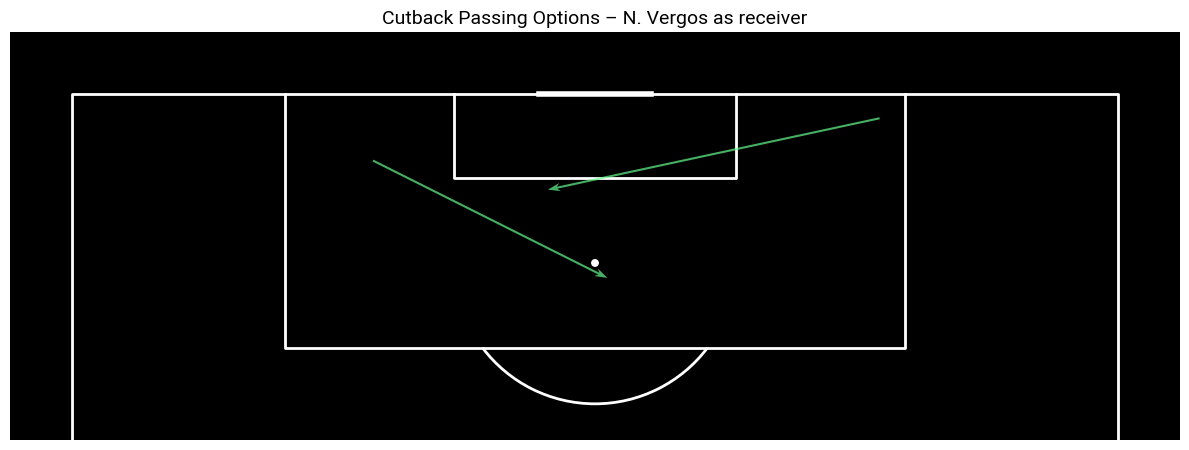

In [7]:
# Filter options (choose only one or leave all as None)
TEAM_TO_PLOT = None         # e.g. "Liverpool"
PASSER_TO_PLOT = None       # e.g. "Mohamed Salah"
RECEIVER_TO_PLOT = "N. Vergos"     # e.g. "D. Núñez"
MATCH_TO_PLOT = None        # e.g. 2018571

# Validate input: only one filter at a time
filters = [TEAM_TO_PLOT, PASSER_TO_PLOT, RECEIVER_TO_PLOT, MATCH_TO_PLOT]
if sum(f is not None for f in filters) > 1:
    raise ValueError("Please set only one of TEAM_TO_PLOT, PLAYER_TO_PLOT or MATCH_TO_PLOT.")

# Copy and apply filter
df_plot = df_cutbacks.copy()
if TEAM_TO_PLOT is not None:
    df_plot = df_plot[df_plot['team_shortname'] == TEAM_TO_PLOT]
elif PASSER_TO_PLOT is not None:
    df_plot = df_plot[df_plot['player_in_possession_name'] == PASSER_TO_PLOT]
elif RECEIVER_TO_PLOT is not None:
    df_plot = df_plot[df_plot['player_name'] == RECEIVER_TO_PLOT]
elif MATCH_TO_PLOT is not None:
    df_plot = df_plot[df_plot['match_id'] == MATCH_TO_PLOT]

# Draw the pitch
pitch = VerticalPitch(
    pitch_type='skillcorner',
    pitch_length=105, pitch_width=68,
    pitch_color='black', line_color='white',
    half=True, pad_bottom=-30
)
fig, ax = pitch.draw(figsize=(12, 8))

# Define the plotting function
def plot_action(row):
    factor_pitch_size_x = 105 / row['pitch_length']
    factor_pitch_size_y = 68 / row['pitch_width']

    pip_x_end = row['player_in_possession_x_end'] * factor_pitch_size_x
    pip_y_end = row['player_in_possession_y_end'] * factor_pitch_size_y
    rec_x_end = row['x_end'] * factor_pitch_size_x
    rec_y_end = row['y_end'] * factor_pitch_size_y

    # Customize color/style here if needed
    pitch.arrows(
        pip_x_end, pip_y_end, rec_x_end, rec_y_end,
        width=1.5, headwidth=4, headlength=6, color='#63FC8E', ax=ax, alpha=0.7
    )

# Plot each cutback
for _, row in df_plot.iterrows():
    plot_action(row)

# Add title
title = "Cutback Passing Options"
if TEAM_TO_PLOT:
    title += f" – {TEAM_TO_PLOT}"
elif PASSER_TO_PLOT:
    title += f" – {PASSER_TO_PLOT} as passer"
elif RECEIVER_TO_PLOT:
    title += f" – {RECEIVER_TO_PLOT} as receiver"
elif MATCH_TO_PLOT:
    title += f" – Match {MATCH_TO_PLOT}"
ax.set_title(title, fontsize=14, fontname="Roboto")
plt.show()

## 📊 5. Player-Level Aggregation

In [8]:
def get_cutback_stats(df_minutes, df_devents, player_type='passer',
                      min_matches=1, min_minutes_per_match=60,
                      min_chances=0, min_try_30tip=0):
    """
    CUTBACK ANALYSIS - Aggregate cutback statistics at player level

    Parameters:
    -----------
    player_type : {'passer', 'receiver'}, default 'passer'
        Defines whether to aggregate stats from the passer's or receiver's perspective
    min_matches : int, default 6
        Minimum number of matches required (with sufficient minutes each)
    min_minutes_per_match : int, default 60
        Minimum minutes per match to count as valid playing time
    min_chances : int, default 10
        Minimum cutback opportunities required to include player
    min_try_30tip : float, default 0
        Minimum attempts per 30min time in possession required

    💡 TIP: Start with default parameters, then adjust min_chances and min_try_30tip to focus on players with sufficient data
    """

    # Configure column names based on analysis perspective
    if player_type == 'passer':
        player_id_col = 'player_in_possession_id'
        player_name_col = 'player_in_possession_name'
    elif player_type == 'receiver':
        player_id_col = 'player_id'
        player_name_col = 'player_name'
    else:
        raise ValueError(f"❌ Invalid player type: {player_type}. Use 'passer' or 'receiver'")

    print(f"🔍 Analyzing cutbacks from {player_type} perspective...")
    df_devents = df_devents.copy()

    # Apply spatial rules to identify cutback situations
    print("   → Detecting cutbacks using spatial rules...")
    df_devents['is_cutback'] = df_devents.apply(
        lambda row: is_cutback(row, pitch_length=row['pitch_length']),
        axis=1
    )

    cutbacks = df_devents[df_devents['is_cutback']==True].copy()
    cutbacks[player_id_col] = cutbacks[player_id_col].astype("Int64")

    # Create flags for successful outcomes (casting to int for math consistency)
    cutbacks["targeted"] = cutbacks["targeted"].astype(int)
    cutbacks["received_and_targeted"] = (cutbacks["received"] & cutbacks["targeted"]).astype(int)
    cutbacks["lead_to_shot_valid"] = (cutbacks["received_and_targeted"] & cutbacks["lead_to_shot"]).astype(int)
    cutbacks["lead_to_goal_valid"] = (cutbacks["received_and_targeted"] & cutbacks["lead_to_goal"]).astype(int)

    print(f"   → Found {len(cutbacks)} cutback situations")

    # Only include players with sufficient playing time
    print(f"   → Filtering players with sufficient minutes (≥{min_matches} matches, ≥{min_minutes_per_match}min each)...")
    df_minutes_clean = df_minutes.drop_duplicates(subset=["player_id"])
    df_minutes_clean["valid_match"] = df_minutes_clean["minutes_full_all"] >= min_minutes_per_match

    valid_ids = (
        df_minutes_clean.groupby("player_id")["valid_match"]
        .sum()
        .reset_index()
        .query(f"valid_match >= {min_matches}")["player_id"]
        .unique()
    )

    # Total playing time per player
    minutes_total = (
        df_minutes.groupby("player_id")[["minutes_full_all", "minutes_full_tip", "count_match"]]
        .sum()
        .reset_index()
        .rename(columns={
            "player_id": player_id_col,
            "minutes_full_all": "minutes_all",
            "minutes_full_tip": "minutes_tip"
        })
    )

    # Different metrics for passers vs receivers
    print(f"   → Calculating {player_type} statistics...")

    if player_type == 'receiver':
        # For receivers: focus on opportunities received and conversion rates
        stats = cutbacks.groupby(player_id_col).agg(
            cutbacks_option_total=('match_id', 'count'),
            cutbacks_targeted=('targeted', 'sum'),
            cutbacks_received=('received_and_targeted', 'sum'),
            cutbacks_to_shot=('lead_to_shot_valid', 'sum'),
            cutbacks_to_goal=('lead_to_goal_valid', 'sum')
        ).reset_index()

        # Calculate conversion ratios
        stats["cutbacks_ignored"] = stats["cutbacks_option_total"] - stats["cutbacks_targeted"]
        stats["cutbacks_targeted_ratio"] = stats["cutbacks_targeted"] / stats["cutbacks_option_total"].replace(0, np.nan)
        stats["cutbacks_received_ratio"] = stats["cutbacks_received"] / stats["cutbacks_targeted"].replace(0, np.nan)
        stats["cutbacks_shot_ratio_from_targeted"] = stats["cutbacks_to_shot"] / stats["cutbacks_targeted"].replace(0, np.nan)
        stats["cutbacks_goal_ratio_from_targeted"] = stats["cutbacks_to_goal"] / stats["cutbacks_targeted"].replace(0, np.nan)

    elif player_type == 'passer':
        # For passers: focus on decision making and execution

        # First, count unique opportunities (avoid double counting)
        options = (
            cutbacks.drop_duplicates(subset=["match_id", "associated_player_possession_event_id"])
            .groupby(player_id_col)
            .agg(cutbacks_option_total=("associated_player_possession_event_id", "count"))
            .reset_index()
        )

        # Then count attempts and successful completions
        stats = cutbacks.groupby(player_id_col).agg(
            cutbacks_attempts=("targeted", "sum"),
            cutbacks_completed=("received_and_targeted", "sum"),
            cutbacks_to_shot=("lead_to_shot_valid", "sum"),
            cutbacks_to_goal=("lead_to_goal_valid", "sum")
        ).reset_index()

        # Merge and calculate decision/execution ratios
        stats = stats.merge(options, on=player_id_col, how="right").fillna(0)
        stats["cutbacks_not_taken"] = stats["cutbacks_option_total"] - stats["cutbacks_attempts"]
        stats["cutbacks_attempts_ratio"] = stats["cutbacks_attempts"] / stats["cutbacks_option_total"].replace(0, np.nan)
        stats["cutbacks_completed_ratio"] = stats["cutbacks_completed"] / stats["cutbacks_attempts"].replace(0, np.nan)
        stats["cutbacks_shot_ratio_from_attempts"] = stats["cutbacks_to_shot"] / stats["cutbacks_attempts"].replace(0, np.nan)
        stats["cutbacks_goal_ratio_from_attempts"] = stats["cutbacks_to_goal"] / stats["cutbacks_attempts"].replace(0, np.nan)

    # Replace NaN values with 0 for better analysis
    ratio_columns = [col for col in stats.columns if 'ratio' in col]
    for col in ratio_columns:
        stats[col] = stats[col].fillna(0.0)

    # Combine statistics with playing time
    df = stats.merge(minutes_total, on=player_id_col, how="left")
    df = df[df[player_id_col].isin(valid_ids)]

    # Create per-90min and per-30min TIP rates
    print("   → Adding normalized metrics (per 90min & per 30min TIP)...")
    cutback_count_columns = [col for col in stats.columns
                            if col.startswith("cutbacks_") and "ratio" not in col]

    for col in cutback_count_columns:
        # AVG(metric_per_match) * 30 / AVG(minutes_tip)
        # (total_metric/n_matches) * 30 / (total_minutes_tip/n_matches) = total_metric * 30 / total_minutes_tip)
        df[f"{col}_p90"] = (df[col] / df["count_match"]) * 90 / (df["minutes_all"] / df["count_match"])

        df[f"{col}_p30tip"] = (df[col] / df["count_match"]) * 30 / (df["minutes_tip"] / df["count_match"])

    # Make results more readable
    name_map = cutbacks[[player_id_col, player_name_col]].drop_duplicates()
    df = df.merge(name_map, on=player_id_col, how="left")

    # Put player name as first column for easy reading
    cols = df.columns.tolist()
    cols.remove(player_name_col)
    df = df[[player_name_col] + cols]

    # Apply minimum thresholds
    final_df = df[
        (df['cutbacks_option_total'] >= min_chances) &
        (df['cutbacks_option_total_p30tip'] >= min_try_30tip)
    ]

    print(f"✅ Analysis complete! Found {len(final_df)} {player_type}s meeting criteria")
    print(f"   → Minimum {min_chances} opportunities, {min_try_30tip} per 30min TIP")

    return final_df

# Basic Analysis


In [9]:
df_receivers = get_cutback_stats(players_df, events_df, player_type='receiver')
df_receivers.sort_values('cutbacks_option_total', ascending=False).head(10)

🔍 Analyzing cutbacks from receiver perspective...
   → Detecting cutbacks using spatial rules...
   → Found 56 cutback situations
   → Filtering players with sufficient minutes (≥1 matches, ≥60min each)...
   → Calculating receiver statistics...
   → Adding normalized metrics (per 90min & per 30min TIP)...
✅ Analysis complete! Found 31 receivers meeting criteria
   → Minimum 0 opportunities, 0 per 30min TIP


,player_name,player_id,cutbacks_option_total,cutbacks_targeted,cutbacks_received,cutbacks_to_shot,cutbacks_to_goal,cutbacks_ignored,cutbacks_targeted_ratio,cutbacks_received_ratio,cutbacks_shot_ratio_from_targeted,cutbacks_goal_ratio_from_targeted,minutes_all,minutes_tip,count_match,cutbacks_option_total_p90,cutbacks_option_total_p30tip,cutbacks_targeted_p90,cutbacks_targeted_p30tip,cutbacks_received_p90,cutbacks_received_p30tip,cutbacks_to_shot_p90,cutbacks_to_shot_p30tip,cutbacks_to_goal_p90,cutbacks_to_goal_p30tip,cutbacks_ignored_p90,cutbacks_ignored_p30tip
8,G. May,38673,5,3,1,1,0,2,0.600000,0.333333,0.333333,0.0,384.75,102.05,4,1.169591,1.469868,0.701754,0.881921,0.233918,0.293974,0.233918,0.293974,0.000000,0.000000,0.467836,0.587947
23,M. Caputo,159945,4,2,2,1,1,2,0.500000,1.000000,0.500000,0.5,86.13,29.98,1,4.179728,4.002668,2.089864,2.001334,2.089864,2.001334,1.044932,1.000667,1.044932,1.000667,2.089864,2.001334
18,L. Rogerson,133501,3,1,1,0,0,2,0.333333,1.000000,0.000000,0.0,309.72,86.42,4,0.871755,1.041426,0.290585,0.347142,0.290585,0.347142,0.000000,0.000000,0.000000,0.000000,0.581170,0.694284
29,C. Piper,957734,2,1,1,1,1,1,0.500000,1.000000,1.000000,1.0,100.47,20.76,2,1.791580,2.890173,0.895790,1.445087,0.895790,1.445087,0.895790,1.445087,0.895790,1.445087,0.895790,1.445087
3,P. Klimala,17231,2,0,0,0,0,2,0.000000,0.000000,0.000000,0.0,83.40,26.65,1,2.158273,2.251407,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.158273,2.251407
6,A. Kuen,26095,2,1,0,0,0,1,0.500000,0.000000,0.000000,0.0,76.98,28.02,1,2.338270,2.141328,1.169135,1.070664,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.169135,1.070664
7,N. Vergos,29075,2,1,1,1,0,1,0.500000,1.000000,1.000000,0.0,153.35,42.80,2,1.173785,1.401869,0.586893,0.700935,0.586893,0.700935,0.586893,0.700935,0.000000,0.000000,0.586893,0.700935
20,A. Segecic,133854,2,2,0,0,0,0,1.000000,0.000000,0.000000,0.0,121.18,32.89,2,1.485394,1.824263,1.485394,1.824263,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,Z. Machach,11117,2,0,0,0,0,2,0.000000,0.000000,0.000000,0.0,183.18,50.29,2,0.982640,1.193080,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.982640,1.193080
11,N. Velupillay,50955,2,0,0,0,0,2,0.000000,0.000000,0.000000,0.0,183.18,50.29,2,0.982640,1.193080,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.982640,1.193080


In [10]:
df_passers = get_cutback_stats(players_df, events_df, player_type='passer')
df_passers.sort_values('cutbacks_attempts', ascending=False).head(10)

🔍 Analyzing cutbacks from passer perspective...
   → Detecting cutbacks using spatial rules...
   → Found 56 cutback situations
   → Filtering players with sufficient minutes (≥1 matches, ≥60min each)...
   → Calculating passer statistics...
   → Adding normalized metrics (per 90min & per 30min TIP)...
✅ Analysis complete! Found 25 passers meeting criteria
   → Minimum 0 opportunities, 0 per 30min TIP


,player_in_possession_name,player_in_possession_id,cutbacks_attempts,cutbacks_completed,cutbacks_to_shot,cutbacks_to_goal,cutbacks_option_total,cutbacks_not_taken,cutbacks_attempts_ratio,cutbacks_completed_ratio,cutbacks_shot_ratio_from_attempts,cutbacks_goal_ratio_from_attempts,minutes_all,minutes_tip,count_match,cutbacks_attempts_p90,cutbacks_attempts_p30tip,cutbacks_completed_p90,cutbacks_completed_p30tip,cutbacks_to_shot_p90,cutbacks_to_shot_p30tip,cutbacks_to_goal_p90,cutbacks_to_goal_p30tip,cutbacks_option_total_p90,cutbacks_option_total_p30tip,cutbacks_not_taken_p90,cutbacks_not_taken_p30tip
12,D. Pierias,51005,2,1,1,0,3,1,0.666667,0.5,0.5,0.0,96.00,24.64,1,1.875000,2.435065,0.937500,1.217532,0.937500,1.217532,0.000000,0.000000,2.812500,3.652597,0.937500,1.217532
23,K. Rahmani,963054,2,1,1,1,2,0,1.000000,0.5,0.5,0.5,85.87,34.20,2,2.096192,1.754386,1.048096,0.877193,1.048096,0.877193,1.048096,0.877193,2.096192,1.754386,0.000000,0.000000
24,L. Gillion,965685,2,2,1,0,2,0,1.000000,1.0,0.5,0.0,194.95,53.30,3,0.923314,1.125704,0.923314,1.125704,0.461657,0.562852,0.000000,0.000000,0.923314,1.125704,0.000000,0.000000
14,A. Cáceres,51045,1,1,0,0,1,0,1.000000,1.0,0.0,0.0,190.65,56.93,2,0.472069,0.526963,0.472069,0.526963,0.000000,0.000000,0.000000,0.000000,0.472069,0.526963,0.000000,0.000000
5,K. Barbarouses,23909,1,0,0,0,2,1,0.500000,0.0,0.0,0.0,199.67,46.61,2,0.450744,0.643639,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.901487,1.287277,0.450744,0.643639
6,A. Ouahim,25534,1,0,0,0,1,0,1.000000,0.0,0.0,0.0,110.85,34.74,2,0.811908,0.863558,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.811908,0.863558,0.000000,0.000000
9,N. Moreno,43829,1,0,0,0,1,0,1.000000,0.0,0.0,0.0,151.10,34.00,4,0.595632,0.882353,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.595632,0.882353,0.000000,0.000000
21,H. Politidis,771857,1,1,0,0,1,0,1.000000,1.0,0.0,0.0,111.59,34.12,2,0.806524,0.879250,0.806524,0.879250,0.000000,0.000000,0.000000,0.000000,0.806524,0.879250,0.000000,0.000000
11,J. Rawlins,50977,1,1,1,0,1,0,1.000000,1.0,1.0,0.0,137.25,37.06,2,0.655738,0.809498,0.655738,0.809498,0.655738,0.809498,0.000000,0.000000,0.655738,0.809498,0.000000,0.000000
20,M. Francois,582974,1,0,0,0,1,0,1.000000,0.0,0.0,0.0,111.57,28.66,2,0.806668,1.046755,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.806668,1.046755,0.000000,0.000000


## ✅ 6. Conclusion & Next Steps

This notebook showed how to detect and analyze cutback opportunities using SkillCorner data.

You learned how to:
- Detect cutbacks based on spatial criteria,
- Aggregate statistics at the player level (as passer or receiver),
- Normalize metrics per 90 minutes or per 30 minutes in possession (TIP),
- Filter players based on minimum playing time and event volume.

---

## 🔧 What you can do next

- Run this on a full season or multiple seasons of dynamic events
- Change the cutback zone definitions if needed **(although we recommend the current ones as a solid baseline)**,
- Adjust filters to match your club’s standards (e.g. number of matches, min chances),
- Switch from "passer" to "receiver" analysis,
- Combine this with internal scouting data or video clips,
- Build your own player evaluation metrics,
- ...

This notebook is designed to be modular, feel free to fork it, adapt it, or plug it into your own workflows.

If you need support using or expanding this, we’re here to help.